In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [52]:
df=pd.read_csv("17) shop_smart_ecommerce.csv")

In [53]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [54]:
df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Text(0.5, 1.0, 'Revenue Yes or No')

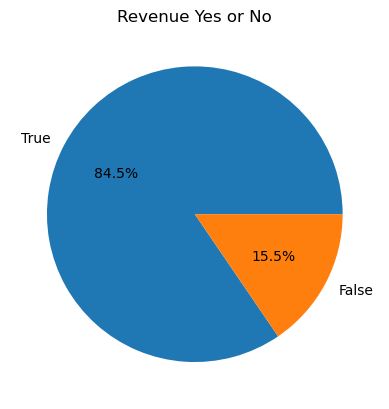

In [55]:
plt.pie(df["Revenue"].value_counts(),labels=["True","False"],autopct="%1.1f%%")
plt.title("Revenue Yes or No")

[Text(0, 0, '10551'), Text(0, 0, '1694'), Text(0, 0, '85')]

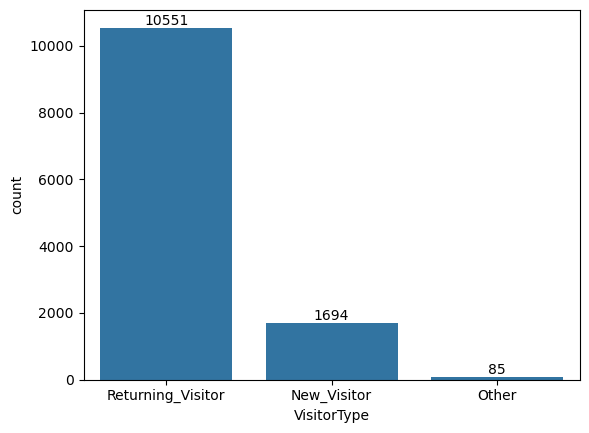

In [56]:
ax=sns.barplot(df["VisitorType"].value_counts())
ax.bar_label(ax.containers[0])

TypeError: 'Figure' object is not subscriptable

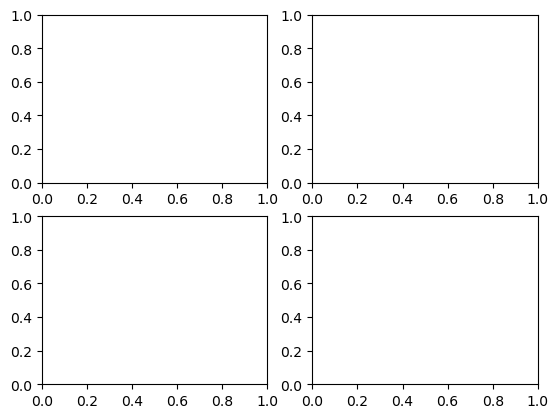

In [58]:
axes,fig=plt.subplots(2,2)
sns.boxplot(ax=axes[0][0],data=df,x="Revenue",y="BounceRates")

In [34]:
le=LabelEncoder()
df["Revenue"]=le.fit_transform(df["Revenue"])
df["Weekend"]=le.fit_transform(df["Weekend"])
df["VisitorType"]=le.fit_transform(df["VisitorType"])
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,2,1,0


In [35]:
df = pd.get_dummies(df, columns=['Month'], dtype=int,drop_first=True)

In [36]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0


<Axes: >

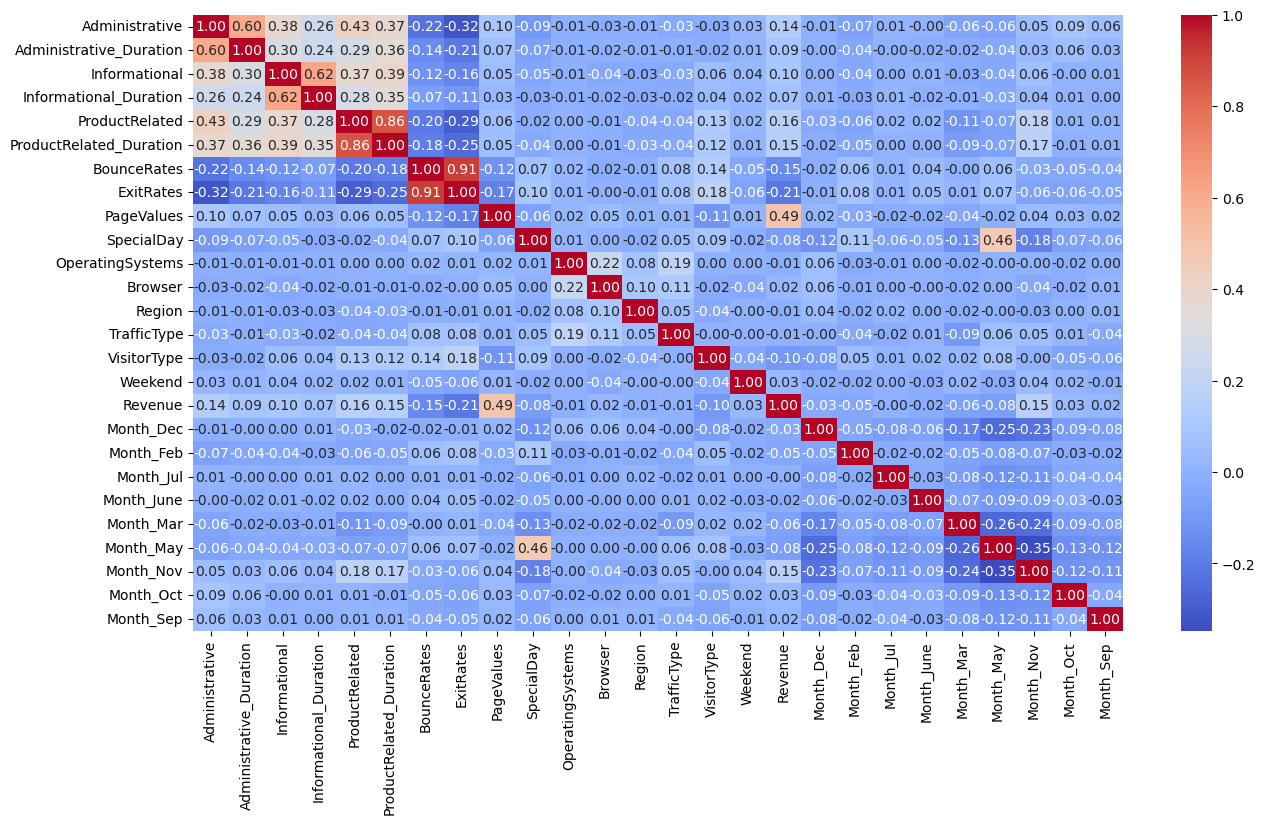

In [37]:
nums_cols=df.select_dtypes(include="number")
corr_matrix=nums_cols.corr()
nums_cols.corr()["Revenue"].sort_values(ascending=False)
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix,
           annot=True,
           fmt=".2f",
            cmap="coolwarm")

In [15]:
X=df.drop("Revenue",axis=1)
y=df["Revenue"]
pipeline = Pipeline([
    ('DT', DecisionTreeClassifier(random_state=42,max_depth=4,min_samples_split=20))
])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
print("F1_score: ",f1_score(y_test,y_pred))
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))
print("Classification Report:",classification_report(y_test,y_pred))

F1_score:  0.648
Confusion Matrix:  [[1959   96]
 [ 168  243]]
Classification Report:               precision    recall  f1-score   support

           0       0.92      0.95      0.94      2055
           1       0.72      0.59      0.65       411

    accuracy                           0.89      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.89      0.89      2466

